# TP3 — Diffusion intelligente : un agent Q-Learning au volant de la radio  (CORRIGÉ)


### Module ISAC — réseaux véhiculaires coopératifs

**Comment travailler ce TP**
- Exécuter les cellules **dans l'ordre** (Maj+Entrée).
- Compléter les zones `TODO` (remplacer les `...`).
- Les blocs **Question** attendent une réponse écrite et argumentée.
- Le TP se déroule en deux parties, **A puis B**, qui s'enchaînent.

**Le fil rouge du module.**
- **TP1** : représenter le réseau par un **graphe** et diffuser par **flooding / gossip** — des règles *fixes*.
- **TP2** : percevoir (le « S » de l'ISAC), et choisir **quoi** transmettre sous contraintes (**VoI**) — une règle *fixe* plus fine.
- **TP3** : et si le véhicule apprenait **tout seul** *comment* transmettre selon la situation ?
  Chaque véhicule embarque un petit « cerveau » vide au départ : il observe, décide, reçoit une **note** (la récompense),
  et au fil des simulations il sait exactement quoi faire dans chaque situation. C'est le **Q-Learning**,
  la forme la plus simple d'**apprentissage par renforcement** (Reinforcement Learning, RL) — une *IA légère*,
  sans réseau de neurones : juste un tableau de scores.


# Partie A — L'agent qui apprend : les briques du Q-Learning


## 1. Pourquoi apprendre ? Les limites des règles fixes

Au TP2, chaque protocole appliquait la **même règle tout le temps** :
- le **flooding** émet toujours à tous ses voisins → excellente couverture, mais airtime énorme et pertes massives en zone dense ;
- le **gossip** émet toujours à un seul voisin → économe, mais lent quand une alerte critique doit circuler ;

Or la *bonne* action **dépend de la situation** : seul avec une alerte accident → inonder ; entouré de 10 voisins avec
une simple info météo → se taire et laisser le canal libre. Plutôt que d'écrire ces règles à la main (et d'en oublier),
on va laisser chaque véhicule les **découvrir par essai-erreur**.

Le cadre est celui de l'apprentissage par renforcement :
à chaque pas de temps, l'agent observe un **État** $S$, choisit une **Action** $A$, touche une **Récompense** $R$,
et observe l'état suivant $S'$. Sa « tête » est une **Q-Table** : un tableau à double entrée où
`Q[S, A]` est le score estimé de l'action $A$ dans l'état $S$. Plus le score est élevé, plus l'action est jugée
intelligente pour cet état.


In [2]:
import numpy as np, networkx as nx, matplotlib.pyplot as plt, time
from IPython import display

tailleMap = 1000

# ---------- Outillage repris des TP1/TP2  ----------
def graphe_proximite(positions, R):
    G = nx.Graph(); N = len(positions)
    for i in range(N): G.add_node(i, pos=positions[i])
    for i in range(N):
        for j in range(i+1, N):
            if np.linalg.norm(positions[i]-positions[j]) <= R:
                G.add_edge(i, j)
    return G

def generer_positions(N, steps, vmax, tailleMap, seed=None):
    rng=np.random.default_rng(seed); pos=rng.random((N,2))*tailleMap
    vel=(rng.random((N,2))-0.5)*vmax; traj=[]
    for _ in range(steps):
        pos+=vel; hors=(pos<0)|(pos>tailleMap); vel[hors]*=-1
        pos=np.clip(pos,0,tailleMap); traj.append(pos.copy())
    return traj

class Event:
    def __init__(self, eid, x, y, importance, naissance, ttl, couleur, kind, relevance):
        self.id=eid; self.pos=np.array([x,y],dtype=float); self.importance=importance
        self.naissance=naissance; self.ttl=ttl; self.couleur=couleur
        self.kind=kind; self.relevance=relevance
    def actif(self, t): return self.naissance <= t < self.naissance + self.ttl

def pertinent(pos, e):
    return np.linalg.norm(pos - e.pos) <= e.relevance

def voi(importance, age):
    return importance * (1.0/(1.0+age))

ACCIDENT_ID = 101
CATEGORIES = [('obstacle', 0.7, 'purple', 55, 'CPM', 250),
              ('travaux', 0.6, 'gold', 70, 'CPM', 200),
              ('ralentissement', 0.5, 'orange', 45, 'CPM', 180),
              ('meteo', 0.2, 'skyblue', 90, 'CPM', 120)]

def make_events(n, steps, tailleMap, seed=None):
    rng = np.random.default_rng(seed)
    evs = [Event(ACCIDENT_ID, 300, 700, 0.9, 0, steps, 'red', 'DENM', 350)]

    # On définit 4 poids pour correspondre aux 4 lignes de CATEGORIES
    poids = np.array([1, 1.5, 2, 3], float)
    poids /= poids.sum()

    for k in range(n-1):
        # Utilisation de len(CATEGORIES) (qui vaut 4) pour éviter l'erreur d'indice
        lab, imp, col, ttl0, kind, rel = CATEGORIES[rng.choice(len(CATEGORIES), p=poids)]
        x, y = rng.random(2)*tailleMap
        naissance = int(rng.integers(0, max(1, steps-30)))
        ttl = max(20, int(ttl0 + rng.integers(-15, 16)))
        evs.append(Event(200+k, x, y, imp, naissance, ttl, col, kind, rel))
    return evs

def perception_ponderee(mem, events, positions, t, N):
    tot = gagne = 0.0
    for e in events:
        if not e.actif(t): continue
        for i in range(N):
            if pertinent(positions[i], e):
                tot += e.importance
                if e.id in mem[i]: gagne += e.importance
    return 100.0*gagne/tot if tot>0 else 100.0

def couverture_evenement(mem, eid, events, positions, t, N):
    e = next(x for x in events if x.id==eid)
    if not e.actif(t): return 0.0
    concernes = [i for i in range(N) if pertinent(positions[i], e)]
    if not concernes: return 0.0
    savent = sum(1 for i in concernes if eid in mem[i])
    return 100.0*savent/len(concernes)

print('Outillage TP1/TP2 chargé.')


Outillage TP1/TP2 chargé.


## 2. L'état : ce que le véhicule « voit »

Pour que l'IA reste **légère**, l'espace d'états doit être **minuscule** : on **discrétise** les grandeurs continues.
Un véhicule n'a besoin de regarder que **deux indicateurs locaux** :

1. **La densité locale de voisins** — y a-t-il du monde autour de moi ?
   - `0` : faible (≤ 3 véhicules à portée) → risque de **rupture de connectivité** ;
   - `1` : forte (> 3 véhicules) → risque de **saturation** du canal.
2. **La criticité de l'information la plus urgente** que je détiens en mémoire :
   - `0` : basse (ex. une simple info météo, CPM peu important) ;
   - `1` : haute (ex. un accident **DENM**, importance ≥ 0.6).

Soit **4 états** au total :

| État | Densité | Urgence |
|---|---|---|
| **E0** | faible | basse |
| **E1** | faible | **HAUTE** |
| **E2** | **FORTE** | basse |
| **E3** | **FORTE** | **HAUTE** |


véhicule 0 (1 voisin, mémoire vide)      -> E0 dens.faible/urg.basse
véhicule 0 (1 voisin, alerte en mémoire) -> E1 dens.faible/urg.HAUTE
véhicule 2 (4 voisins, alerte)           -> E3 dens.FORTE/urg.HAUTE


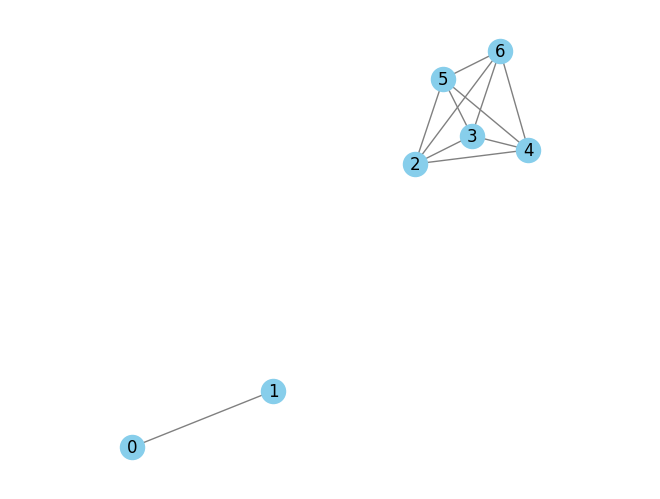

In [3]:
SEUIL_DENSITE = 3     # <= 3 voisins -> densité faible
SEUIL_URGENCE = 0.6   # importance max en mémoire >= 0.6 -> urgence haute
N_ETATS, N_ACTIONS = 4, 3
NOM_ETATS   = ['E0 dens.faible/urg.basse','E1 dens.faible/urg.HAUTE',
               'E2 dens.FORTE/urg.basse','E3 dens.FORTE/urg.HAUTE']
NOM_ACTIONS = ['A0 Attendre','A1 Gossip','A2 Flooding']

def etat_vehicule(G, i, mem_i, ebyid, t):
    """Discrétise ce que voit le véhicule i -> un entier dans {0,1,2,3}.
       G     : graphe de proximité du moment
       mem_i : mémoire du véhicule i, {event_id: instant_observation}
       ebyid : {event_id: Event}"""
    n_voisins = G.degree(i)
    densite = 1 if n_voisins > SEUIL_DENSITE else 0
    urgence = 0
    for eid in mem_i:
        if ebyid[eid].importance >= SEUIL_URGENCE:
            urgence = 1; break
    return densite*2 + urgence   # ça retourne 0 , 1 , 2 ou 3 et chaque numéro correspond à l'état correspondant

# --- test rapide sur une scène jouet ---
pos_test = np.array([[100.,100.],[150.,120.],[200.,200.],[220.,210.],[240.,205.],[210.,230.],[230.,240.]])
G_test = graphe_proximite(pos_test, R=80)
ev_test = Event(999, 0, 0, 0.9, 0, 100, 'red', 'DENM', 1000)
ebyid_test = {999: ev_test}
print('véhicule 0 (1 voisin, mémoire vide)      ->', NOM_ETATS[etat_vehicule(G_test, 0, {}, ebyid_test, 0)])
print('véhicule 0 (1 voisin, alerte en mémoire) ->', NOM_ETATS[etat_vehicule(G_test, 0, {999:0}, ebyid_test, 0)])
print('véhicule 2 (4 voisins, alerte)           ->', NOM_ETATS[etat_vehicule(G_test, 2, {999:0}, ebyid_test, 0)])


pos_dict = {i: pos for i, pos in enumerate(pos_test)}
nx.draw(G_test, pos_dict, with_labels=True, node_color='skyblue', edge_color='gray')
plt.axis('equal')
plt.show()

## 3. Les actions et la Q-Table

À chaque pas de temps, le véhicule choisit **une action parmi trois** :

- **A0 — Attendre** : ne rien transmettre (économiser le canal) ;
- **A1 — Gossip** : transmettre sa mémoire à **un seul** voisin tiré au hasard ;
- **A2 — Flooding** : transmettre à **tous** les voisins à portée.

La « tête » de l'agent est une simple **matrice 4 × 3 initialisée à zéro** — c'est toute l'IA :


In [8]:
q_table = np.zeros((N_ETATS, N_ACTIONS))     # 4 états x 3 actions

def afficher_q(q):
    print(f"{'':34s}{NOM_ACTIONS[0]:>14s}{NOM_ACTIONS[1]:>12s}{NOM_ACTIONS[2]:>14s}")
    for s in range(N_ETATS):
        print(f"{NOM_ETATS[s]:34s}" + ''.join(f"{q[s,a]:>13.2f} " for a in range(N_ACTIONS)))

afficher_q(q_table)

                                     A0 Attendre   A1 Gossip   A2 Flooding
E0 dens.faible/urg.basse                   0.00          0.00          0.00 
E1 dens.faible/urg.HAUTE                   0.00          0.00          0.00 
E2 dens.FORTE/urg.basse                    0.00          0.00          0.00 
E3 dens.FORTE/urg.HAUTE                    0.00          0.00          0.00 


## 4. La récompense : le contrat passé avec l'agent

C'est **le cœur du sujet ISAC** : on veut **maximiser la diffusion des alertes** tout en **minimisant la charge réseau**
(l'airtime). La fonction de récompense traduit ce compromis en points :

| Situation | Récompense |
|---|---|
| L'agent **attend** alors qu'il détient une info **critique** et qu'il a des voisins | **−20** (faute grave : l'alerte ne circule pas) |
| L'agent **attend** et rien d'urgent en mémoire | **+1** (économie de canal récompensée) |
| L'agent **transmet** (gossip ou flooding) | **+10 × (infos *nouvelles* livrées, pondérées par importance) − 0.9 × (nb de transmissions)** |

La clé : une transmission ne rapporte que si elle apporte de l'information **nouvelle** à quelqu'un.
Inonder des voisins qui savent déjà tout = coût sans gain → l'agent apprendra tout seul que
le flooding en zone dense **sature pour rien** quand l'info est banale.


In [14]:
def recompense(action, urgence, n_utiles_pond, n_tx, a_des_voisins):
    """action        : 0/1/2
       urgence       : bit d'urgence de l'état courant
       n_utiles_pond : est la somme des importances pour tous les voisins qui découvrent une information qu'ils ne connaissaient pas.
       n_tx          : nombre de transmissions effectuées ce pas
       a_des_voisins : True si le véhicule avait au moins un voisin"""
    if action == 0:                                   # Attendre
        if urgence == 1 and a_des_voisins: return -20.0
        return +1.0
    return 10.0*n_utiles_pond - 0.9*n_tx              # Gossip / Flooding
# --- vérifications ---
assert recompense(0, 1, 0, 0, True)  == -20.0   # Action 0 (se taire) avec urgence = faute critique (inchangé)
assert recompense(0, 0, 0, 0, True)  == +1.0    # Action 0 (se taire) sans urgence = économie (inchangé)
assert recompense(2, 1, 0.9, 5, True) == 10.0 * 0.9 - 0.9 * 5  # = 4.5  Flooder utilement (5 tx à -0.9)

print('Contrat de récompense OK.')

Contrat de récompense OK.


## 5. Explorer ou exploiter : la stratégie $\epsilon$-greedy

Si l'agent choisissait toujours la case au meilleur score, il resterait bloqué sur la première action qui a marché
(les autres cases restent à zéro, jamais essayées). La parade : avec une petite probabilité $\epsilon$, il tente
une action **au hasard** (*exploration*) ; le reste du temps il prend la **meilleure case** (*exploitation*).
Au fil de l'entraînement on fait **décroître** $\epsilon$ : beaucoup d'essais au début, du sérieux à la fin.


In [15]:
def choisir_action(q_table, s, epsilon, rng):
    """Epsilon-greedy : explorer avec proba epsilon, sinon exploiter argmax."""
    if rng.random() < epsilon:
        return int(rng.integers(0, N_ACTIONS))       # exploration soit 0 ou 1 ou 2
    return int(np.argmax(q_table[s]))                # exploitation soit 0 ou 1 ou 2

# --- petit contrôle statistique : epsilon=0.3 => ~30% d'actions aléatoires ---
rng = np.random.default_rng(0)
q_demo = np.array([[0., 5., 1.]])                    # 1 état, meilleure action = A1 (car le score associé est 5)
tirages = [choisir_action(q_demo, 0, 0.3, rng) for _ in range(3000)]   # tirage est égal à 0, 1 ou 2
part_a1 = tirages.count(1)/len(tirages)
print(f"Part de A1 choisie : {part_a1:.2%} (attendu ~ 0.7 + 0.3/3 = 80%)")

Part de A1 choisie : 80.23% (attendu ~ 0.7 + 0.3/3 = 80%)


## 6. Apprendre : l'équation de Bellman

Après chaque action, l'agent met à jour **une seule case** de sa table :

$$Q[S,A] \;\leftarrow\; Q[S,A] \;+\; \alpha\,\big(\,R \;+\; \gamma\,\max_{a'} Q[S',a'] \;-\; Q[S,A]\,\big)$$

- $\alpha$ (*learning rate*) : vitesse d'apprentissage — quelle part de la surprise on intègre ;
- $\gamma$ (*discount factor*) : importance des récompenses **futures** — l'agent ne regarde pas que le coup présent ;
- $R + \gamma \max_{a'} Q[S',a']$ : ce que le coup **a réellement rapporté** (gain immédiat + meilleur avenir estimé) ;
- la parenthèse entière : **l'erreur de prédiction** (surprise) que l'on corrige petit à petit.


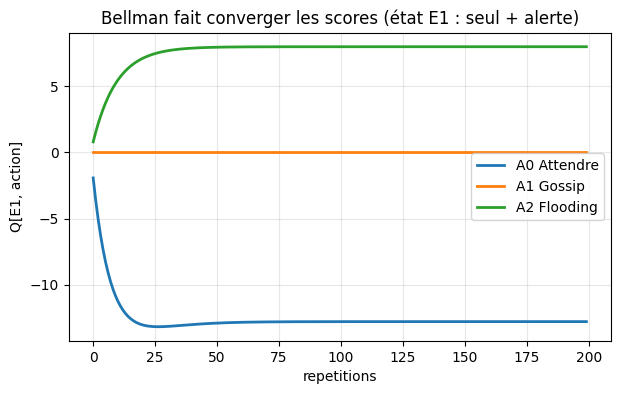

                                     A0 Attendre   A1 Gossip   A2 Flooding
E0 dens.faible/urg.basse                   0.00          0.00          0.00 
E1 dens.faible/urg.HAUTE                 -12.80          0.00          8.00 
E2 dens.FORTE/urg.basse                    0.00          0.00          0.00 
E3 dens.FORTE/urg.HAUTE                    0.00          0.00          0.00 


In [17]:
def maj_bellman(q_table, s, a, r, s2, alpha=0.1, gamma=0.9):
    q_table[s, a] += alpha * (r + gamma*np.max(q_table[s2]) - q_table[s, a])

# --- scénario jouet scripté : on rejoue 200 fois la MÊME transition et on regarde Q converger ---
# État E1 (seul + alerte). Flooder livre l'info à 1 voisin important (r = 10*0.9 - 1 = +8),
# attendre coûte -20. L'état suivant est E0 (l'alerte est passée).
q_jouet = np.zeros((N_ETATS, N_ACTIONS))
histo = []
for k in range(200):
    maj_bellman(q_jouet, s=1, a=2, r=+8.0,  s2=0)    # flooder l'alerte
    maj_bellman(q_jouet, s=1, a=0, r=-20.0, s2=1)    # se taire (l'alerte reste)
    histo.append(q_jouet[1].copy())
histo = np.array(histo)
plt.figure(figsize=(7,4))
for a in range(N_ACTIONS):
    plt.plot(histo[:,a], label=NOM_ACTIONS[a], linewidth=2)
plt.xlabel('repetitions'); plt.ylabel('Q[E1, action]')
plt.title('Bellman fait converger les scores (état E1 : seul + alerte)')
plt.legend(); plt.grid(alpha=0.3); plt.show()
afficher_q(q_jouet)

**Ce que montre le graphique.** Les deux courbes convergent vers des **valeurs stables**, et c'est exactement le rôle de Bellman :
- **A2 Flooding** monte et se stabilise autour de **+8** : c'est la récompense réelle de la transition ($r=+8$, suivie de l'état E0 dont les Q valent 0). Comme $\alpha=0{,}1$, chaque répétition ne corrige qu'un dixième de l'erreur → la montée est **exponentielle amortie**, pas instantanée.
- **A0 Attendre** descend mais **ne converge pas vers −20** : elle se stabilise vers $\approx -12{,}8$. Pourquoi ? Parce que l'état suivant est **encore E1** (l'alerte reste), et le terme $\gamma\max_{a'}Q[E1,a'] = 0{,}9\times 8 = +7{,}2$ vient *adoucir* la punition : $-20 + 7{,}2 = -12{,}8$. L'agent intègre le fait qu'il pourra **se rattraper au coup suivant** en floodant.
- **A1 Gossip** reste à 0 : jamais essayée dans ce scénario scripté → une case de la Q-table **ne bouge que si l'action est jouée**. C'est l'argument central en faveur de l'exploration $\epsilon$-greedy.

On voit donc les trois ingrédients de Bellman en action : la récompense immédiate $R$, le futur actualisé $\gamma\max Q[S']$, et la vitesse de correction $\alpha$.

# Partie B — L'agent dans la simulation ISAC complète


## 1. La boucle de simulation pilotée par l'agent

On reprend la simulation du TP2 (mobilité, sensing, budgets `MAX_TX`/`MAX_RX`, purge TTL + pertinence) et on remplace
le protocole fixe par **les quatre briques de la Partie A**. À chaque pas de temps, pour chaque véhicule :

1. **Observer** : $S$ = `etat_vehicule(...)` ;
2. **Décider** : $A$ = `choisir_action(...)` → Attendre / Gossip / Flooding ;
3. **Agir** : émission selon $A$ (outbox triée par VoI, budget `MAX_TX`), réception (budget `MAX_RX`) ;
4. **Noter** : $R$ = `recompense(...)` — on **crédite l'émetteur** pour chaque info *nouvelle* réellement livrée ;
5. **Apprendre** : `maj_bellman(...)` avec l'état suivant $S'$ recalculé après les échanges.

Un choix d'architecture important : la Q-table est **partagée** par tous les véhicules
(tous contribuent à la même table et la lisent). C'est comme si la flotte mutualisait son expérience —
et cela accélère énormément l'apprentissage. Chaque véhicule reste **autonome** dans ses décisions :
il ne lit que son état **local**.

Le paramètre `protocole` accepte maintenant `'flooding'`, `'gossip'` et **`'rl'`**.


In [18]:
def simuler(protocole, cfg, events, traj, q_table=None, epsilon=0.0,
            apprendre=False, alpha=0.1, gamma=0.9, seed=0):
    """Simulation ISAC sous contraintes (TP2), pilotable par l'agent RL (TP3).
       protocole in {'flooding', 'gossip', 'rl'}.
       En mode 'rl', chaque véhicule utilise la Q-table PARTAGÉE pour décider son action ;
       si apprendre=True, la table est mise à jour en ligne (Bellman)."""
    N, steps = cfg['N'], cfg['steps']
    R, R_sense = cfg['R'], cfg['R_sense']
    MAX_TX, MAX_RX = cfg['MAX_TX'], cfg['MAX_RX']
    ebyid = {e.id: e for e in events}
    rng = np.random.default_rng(seed)

    mem = {i: {} for i in range(N)}
    cov, tx, crit, rec_hist, act_hist = [], [], [], [], []

    for t in range(steps):
        positions = traj[t]
        actifs = {e.id for e in events if e.actif(t)}
        G = graphe_proximite(positions, R)

        # (a) purge : TTL + pertinence (comme au TP2)
        for i in range(N):
            mem[i] = {eid: ts for eid, ts in mem[i].items()
                      if eid in actifs and pertinent(positions[i], ebyid[eid])}

        # (b) sensing local : horodatage = instant d'observation (AoI)
        for i in range(N):
            for e in events:
                if e.actif(t) and np.linalg.norm(positions[i]-e.pos) <= R_sense:
                    mem[i][e.id] = t

        # (c) OBSERVER + DÉCIDER : états et actions de chaque véhicule
        etats, actions = {}, {}
        for i in range(N):
            s = etat_vehicule(G, i, mem[i], ebyid, t)          # <-  brique A.2
            etats[i] = s
            if protocole == 'rl':
                actions[i] = choisir_action(q_table, s, epsilon, rng)   # <-  brique A.5
            elif protocole == 'flooding':
                actions[i] = 2
            elif protocole == 'gossip':
                actions[i] = 1

        # (d) préparer les outbox (budget MAX_TX) ; 'rl' trie par valeur (VoI)
        outbox = {}
        for i in range(N):
            connus = [{'id':eid,'ts':ts,'voi':voi(ebyid[eid].importance, t-ts),'src':i}
                      for eid, ts in mem[i].items()]
            if protocole == 'rl':
                # L'agent RL classe ses messages par importance pour envoyer les plus critiques
                outbox[i] = sorted(connus, key=lambda x:x['voi'], reverse=True)[:MAX_TX]
            else:
                # Flooding et Gossip sélectionnent leurs messages de manière aléatoire
                rng.shuffle(connus)
                outbox[i] = connus[:MAX_TX]

        # (e) AGIR : émission selon l'action (geocast : on n'envoie qu'aux voisins concernés)
        inbox = {j: [] for j in range(N)}
        tx_i = {i: 0 for i in range(N)}
        for i in range(N):
            if actions[i] == 0 or not outbox[i]: continue
            voisins = list(G.neighbors(i))
            if not voisins: continue

            # Action 1 (Gossip) : Cible unique / Action 2 (Flooding) : Tous les voisins
            cibles = [voisins[int(rng.integers(len(voisins)))]] if actions[i]==1 else voisins

            for j in cibles:
                for msg in outbox[i]:
                    if not pertinent(positions[j], ebyid[msg['id']]): continue
                    tx_i[i] += 1
                    inbox[j].append(msg)

        # (f) réception (budget MAX_RX) ; on CRÉDITE l'émetteur pour chaque info NOUVELLE
        utiles_pond = {i: 0.0 for i in range(N)}
        new_mem = {i: dict(mem[i]) for i in range(N)}
        for j in range(N):
            paquets = inbox[j]
            if not paquets: continue

            if protocole == 'rl':
                # L'agent RL filtre et trie les messages reçus pour garder les plus urgents
                meilleur = {}
                for msg in paquets:
                    cur = mem[j].get(msg['id'])
                    if cur is not None and cur >= msg['ts']: continue
                    if msg['id'] not in meilleur or msg['voi'] > meilleur[msg['id']]['voi']:
                        meilleur[msg['id']] = msg
                gardes = sorted(meilleur.values(), key=lambda x:x['voi'], reverse=True)[:MAX_RX]
            else:
                # Flooding et Gossip réceptionnent au hasard
                rng.shuffle(paquets)
                gardes = paquets[:MAX_RX]

            for msg in gardes:
                cur = new_mem[j].get(msg['id'])
                if cur is None or cur < msg['ts']:
                    new_mem[j][msg['id']] = msg['ts']
                    utiles_pond[msg['src']] += ebyid[msg['id']].importance

        # (g) NOTER + APPRENDRE : récompense puis Bellman (S' recalculé après les échanges)
        r_step = 0.0
        for i in range(N):
            s, a = etats[i], actions[i]
            r = recompense(a, s % 2, utiles_pond[i], tx_i[i],      # <-  brique A.4
                           a_des_voisins=(G.degree(i) > 0)) #s%2 nous permet de savoir si l'action est urgente ou non# donc s%2 = urgence (Rappel s = [0(Non_dense,Non_urg) , 1(Non_dense,urg) ,2(dense,Non_urg) ,3(dense,urg) ] )
            r_step += r
            if apprendre:
                s2 = etat_vehicule(G, i, new_mem[i], ebyid, t)
                maj_bellman(q_table, s, a, r, s2, alpha, gamma)     # <-  brique A.6

        mem = new_mem
        tx.append(sum(tx_i.values()))
        cov.append(perception_ponderee(mem, events, positions, t, N))
        crit.append(couverture_evenement(mem, ACCIDENT_ID, events, positions, t, N))
        rec_hist.append(r_step / N)
        act_hist.append([actions[i] for i in range(N)])

    return {'cov':cov,'tx':tx,'crit':crit,'rec':rec_hist,'actions':act_hist}

## 2. Entraîner l'agent : les épisodes

Un **épisode** = une simulation complète (nouvelles trajectoires, nouveaux événements). On enchaîne les épisodes
avec un $\epsilon$ qui **décroît** ($\epsilon_0=0.4$, décroissance ×0.90 par épisode, plancher 0.02) : l'agent
explore beaucoup au début, exploite à la fin. La Q-table **survit d'un épisode à l'autre** — c'est elle,
la connaissance accumulée.


Entraînement : 40 épisodes en 17.3s


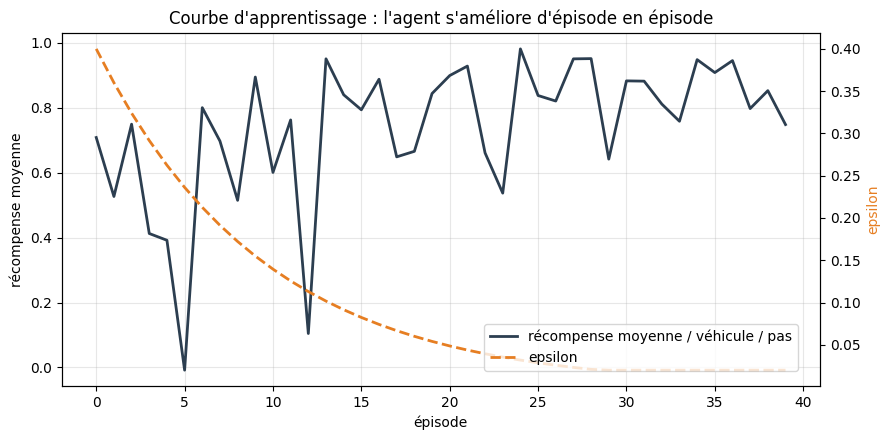

In [20]:
cfg = dict(N=22, R=100, R_sense=90, MAX_TX=2, MAX_RX=3, n_events=15, vmax=9, steps=90)

def entrainer(cfg, n_episodes=40, eps0=0.4, eps_min=0.02, decay=0.90,
              alpha=0.1, gamma=0.9, seed0=100):
    q_table = np.zeros((N_ETATS, N_ACTIONS))
    recompenses, epsilons = [], []
    for ep in range(n_episodes):
        eps = max(eps_min, eps0 * (decay**ep))

        traj   = generer_positions(cfg['N'], cfg['steps'], cfg['vmax'], tailleMap, seed=seed0+ep)
        #À chaque épisode ep, le code change la graine de génération aléatoire (seed0 + ep).
        #Pourquoi ? Si on gardait la même graine, les voitures rouleraient toujours exactement de la même façon et les accidents apparaîtraient toujours aux mêmes endroits.
        #L'IA finirait par apprendre par cœur ce scénario unique (phénomène de surapprentissage ou overfitting).

        events = make_events(cfg['n_events'], cfg['steps'], tailleMap, seed=seed0+ep)
        res = simuler('rl', cfg, events, traj, q_table=q_table, epsilon=eps,
                      apprendre=True, alpha=alpha, gamma=gamma, seed=seed0+ep)
        recompenses.append(np.mean(res['rec']))
        epsilons.append(eps)
    return q_table, recompenses, epsilons

t0 = time.time()
n_episodes_test = 40
q_table, recompenses, epsilons = entrainer(cfg, n_episodes=n_episodes_test)
print(f'Entraînement : {n_episodes_test} épisodes en {time.time()-t0:.1f}s')

fig, ax1 = plt.subplots(figsize=(9,4.5))
ax1.plot(recompenses, color='#2c3e50', linewidth=2, label='récompense moyenne / véhicule / pas')
ax1.set_xlabel('épisode'); ax1.set_ylabel('récompense moyenne'); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(epsilons, color='#e67e22', linestyle='--', linewidth=2, label='epsilon')
ax2.set_ylabel('epsilon', color='#e67e22')
ax1.set_title("Courbe d'apprentissage : l'agent s'améliore d'épisode en épisode")
fig.legend(loc='lower right', bbox_to_anchor=(0.9, 0.15)); plt.tight_layout(); plt.show()

**Ce que montre la courbe d'apprentissage.** Deux dynamiques se superposent :
- La **récompense moyenne par véhicule et par pas** (courbe sombre) part de valeurs médiocres — l'agent choisit souvent au hasard ($\epsilon_0=0{,}4$) et commet des fautes (flooder pour rien, se taire avec une alerte) — puis **monte et se stabilise** : la Q-table encode progressivement une politique rentable.
- L'**epsilon** (pointillés orange) décroît géométriquement (×0,90 par épisode, plancher 0,02) : au début l'agent **explore** (il remplit toutes les cases de la table), à la fin il **exploite** (il joue presque toujours l'argmax). La montée de la récompense suit d'ailleurs de près la chute d'$\epsilon$ : une partie du gain vient de la connaissance acquise, une autre du simple fait qu'on fait moins d'essais aléatoires coûteux.

Deux points de rigueur : (1) la courbe reste **bruitée** car chaque épisode utilise de **nouvelles trajectoires et de nouveaux événements** (seed différent) — c'est volontaire, pour éviter le **surapprentissage** d'un scénario unique ; (2) le plateau final ne signifie pas « politique parfaite », seulement que la table ne change plus beaucoup **pour la distribution de scénarios rencontrée**.

## 3. Lire ce que l'agent a appris

La Q-table finale est **interprétable** — c'est un avantage majeur du Q-Learning tabulaire sur les réseaux de neurones : on peut *lire* la politique ligne par ligne et vérifier qu'elle est raisonnable.

                                     A0 Attendre   A1 Gossip   A2 Flooding
E0 dens.faible/urg.basse                   9.47          8.84          8.85 
E1 dens.faible/urg.HAUTE                  -9.51         -2.90         -2.95 
E2 dens.FORTE/urg.basse                    8.84          2.73          2.33 
E3 dens.FORTE/urg.HAUTE                  -11.34          5.22         -5.76 

Politique apprise :
  E0 dens.faible/urg.basse           -> A0 Attendre
  E1 dens.faible/urg.HAUTE           -> A1 Gossip
  E2 dens.FORTE/urg.basse            -> A0 Attendre
  E3 dens.FORTE/urg.HAUTE            -> A1 Gossip


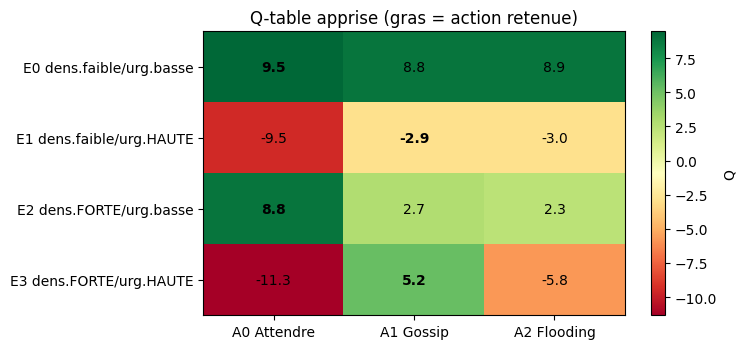

In [21]:
afficher_q(q_table)
print()
print('Politique apprise :')
for s in range(N_ETATS):
    best = int(np.argmax(q_table[s]))
    print(f'  {NOM_ETATS[s]:34s} -> {NOM_ACTIONS[best]}')

# Heatmap de la Q-table
fig, ax = plt.subplots(figsize=(7.5, 3.6))
im = ax.imshow(q_table, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(N_ACTIONS)); ax.set_xticklabels(NOM_ACTIONS)
ax.set_yticks(range(N_ETATS));   ax.set_yticklabels(NOM_ETATS)
for s in range(N_ETATS):
    for a in range(N_ACTIONS):
        poids = 'bold' if a == int(np.argmax(q_table[s])) else 'normal'
        ax.text(a, s, f'{q_table[s,a]:.1f}', ha='center', va='center', fontweight=poids)
plt.colorbar(im, label='Q'); ax.set_title('Q-table apprise (gras = action retenue)')
plt.tight_layout(); plt.show()

**Lecture de la Q-table et de la politique.** Ligne par ligne (les valeurs exactes varient d'un entraînement à l'autre, mais la *structure* est robuste) :

- **E0 (densité faible, urgence basse) → Attendre.** Rien d'urgent, peu de monde à informer : se taire rapporte +1 à chaque pas, transmettre coûte de l'airtime pour un gain d'information faible. L'agent a redécouvert **l'économie de canal**.
- **E2 (densité forte, urgence basse) → Attendre.** C'est le cas le plus intéressant : beaucoup de voisins, mais en zone dense **tout le monde sait déjà à peu près tout** (la perception est largement partagée) → les transmissions apportent peu d'infos *nouvelles* et sont pénalisées par le coût. L'agent a appris seul que **le flooding en zone dense sature pour rien** .
- **E1 et E3 (urgence HAUTE) → transmettre** (ici Gossip). La pénalité de −20 pour le silence coupable rend l'attente inenvisageable : les Q[.,A0] sont très négatifs. Entre Gossip et Flooding, les scores sont proches en E1 (avec ≤3 voisins, un gossip touche une part importante du voisinage pour un coût minimal) ; en E3, le Gossip l'emporte nettement sur le Flooding car flooder en zone dense multiplie les transmissions redondantes (−0,9 chacune) sans livrer beaucoup d'infos nouvelles supplémentaires.

La heatmap résume ce compromis : **colonne « Attendre » verte quand l'urgence est basse, rouge quand elle est haute** — la frontière de décision apprise coïncide avec le bit d'urgence, et l'intensité de la diffusion est modulée par la densité.

## 4. Le match : agent RL contre les règles fixes

On évalue les trois stratégies sur **les mêmes trajectoires et les mêmes événements** de test (jamais vus à
l'entraînement), avec $\epsilon = 0$ (l'agent exploite ce qu'il sait, plus d'exploration).


Évaluation statistique en cours sur 20 seeds indépendants...
Simulation terminée avec succès !


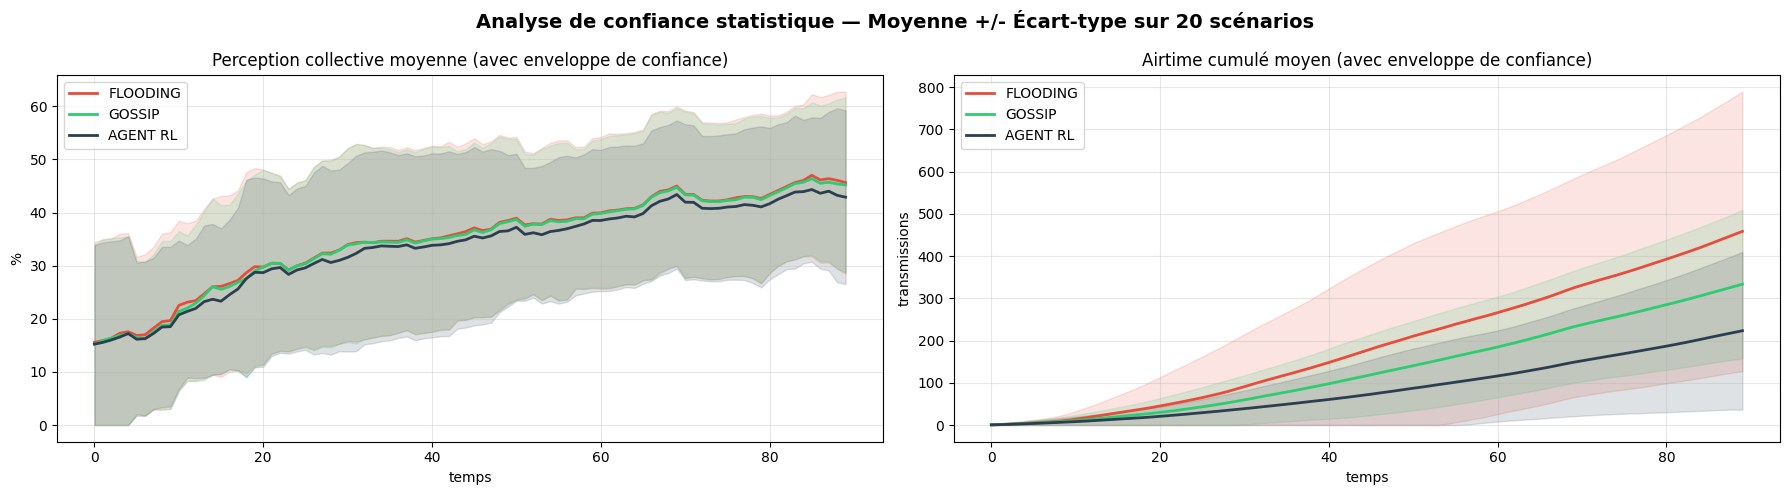

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# CONFIGURATION DU TEST STATISTIQUE (20 SEEDS)
# =============================================================================
N_SEEDS = 20
seeds_test = list(range(1000, 1000 + N_SEEDS))
# Nettoyage : On ne garde que les deux règles fixes de base et notre Agent RL
protocols = ['flooding', 'gossip', 'rl']
steps = cfg['steps']

# Tableaux pour stocker l'historique temporel complet de chaque run (pour l'écart-type graphique)
history_cov = {p: np.zeros((N_SEEDS, steps)) for p in protocols}
history_tx = {p: np.zeros((N_SEEDS, steps)) for p in protocols}

# Listes pour stocker les valeurs finales (pour le bilan textuel)
final_perception = {p: [] for p in protocols}
final_airtime = {p: [] for p in protocols}

print(f"Évaluation statistique en cours sur {N_SEEDS} seeds indépendants...")

for idx_s, s in enumerate(seeds_test):
    traj_s   = generer_positions(cfg['N'], cfg['steps'], cfg['vmax'], tailleMap, seed=s)
    events_s = make_events(cfg['n_events'], cfg['steps'], tailleMap, seed=s)

    for p in protocols:
        res = simuler(p, cfg, events_s, traj_s,
                      q_table=q_table if p=='rl' else None, epsilon=0.0, seed=s)

        # Enregistrement de l'évolution pas à pas
        history_cov[p][idx_s, :] = res['cov']
        history_tx[p][idx_s, :] = np.cumsum(res['tx'])

        # Enregistrement des valeurs à la dernière seconde
        final_perception[p].append(res['cov'][-1])
        final_airtime[p].append(sum(res['tx']))

print("Simulation terminée avec succès !")

# =============================================================================
# TRACÉ DES GRAPHIQUES AVEC ENVELOPPE DE CONFIANCE
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
t_range = range(steps)

titres   = {'flooding':'FLOODING','gossip':'GOSSIP','rl':'AGENT RL'}
couleurs = {'flooding':'#e74c3c','gossip':'#2ecc71','rl':'#2c3e50'}

# --- Graphique 1 : Perception collective moyenne ---
for p in protocols:
    mean_cov = np.mean(history_cov[p], axis=0)
    std_cov = np.std(history_cov[p], axis=0)

    # Courbe moyenne
    axes[0].plot(t_range, mean_cov, label=titres[p], color=couleurs[p], linewidth=2)
    # Zone d'ombre (Confiance / Écart-type)
    axes[0].fill_between(t_range,
                         np.clip(mean_cov - std_cov, 0, 100),
                         np.clip(mean_cov + std_cov, 0, 100),
                         color=couleurs[p], alpha=0.15)

axes[0].set_title('Perception collective moyenne (avec enveloppe de confiance)')
axes[0].set_xlabel('temps')
axes[0].set_ylabel('%')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Graphique 2 : Airtime cumulé moyen ---
for p in protocols:
    mean_tx = np.mean(history_tx[p], axis=0)
    std_tx = np.std(history_tx[p], axis=0)

    # Courbe moyenne
    axes[1].plot(t_range, mean_tx, label=titres[p], color=couleurs[p], linewidth=2)
    # Zone d'ombre (Confiance / Écart-type)
    axes[1].fill_between(t_range,
                         np.maximum(mean_tx - std_tx, 0),
                         mean_tx + std_tx,
                         color=couleurs[p], alpha=0.15)

axes[1].set_title('Airtime cumulé moyen (avec enveloppe de confiance)')
axes[1].set_xlabel('temps')
axes[1].set_ylabel('transmissions')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'Analyse de confiance statistique — Moyenne +/- Écart-type sur {N_SEEDS} scénarios',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



### Observation — analyse du match sur 20 scénarios

**Graphique de gauche (perception collective).** Le **flooding** atteint la meilleure couverture : c'est sa raison d'être, il pousse l'information sur tous les chemins en parallèle. Le **gossip** plafonne plus bas et plus lentement (un seul voisin par pas, sous budget `MAX_TX`). L'**agent RL** se place typiquement **entre les deux, proche du flooding** : il ne transmet que quand l'état le justifie, mais quand une alerte circule, il la relaie en priorité (outbox triée par VoI).

**Graphique de droite (airtime cumulé).** L'ordre s'inverse : le flooding paie sa couverture par un airtime **très supérieur** (croissance quasi linéaire et raide), tandis que l'agent RL obtient sa perception pour un **coût proche du gossip** .


---
**Ce qu'il faut retenir du TP3.**

**Partie A — les briques du Q-Learning**
- Un agent **léger** = un espace d'états **minuscule** (4 états discrétisés : densité × urgence) et une **Q-table** 4×3 lisible.
- La **fonction de récompense** est le vrai programme de l'agent : elle traduit le compromis ISAC (diffuser les alertes / économiser l'airtime) en points. Changer la récompense change la politique apprise.
- **$\epsilon$-greedy** garantit que toutes les cases de la table sont essayées ; **Bellman** propage les gains immédiats *et futurs* ($\gamma$) dans la table, à la vitesse $\alpha$.

**Partie B — l'agent dans la simulation ISAC**
- La Q-table **partagée** mutualise l'expérience de la flotte tout en laissant chaque véhicule **décider localement** : c'est une forme simple d'intelligence distribuée.
- L'entraînement par **épisodes à seeds variés** évite le surapprentissage ; la décroissance d'$\epsilon$ fait passer l'agent de l'exploration à l'exploitation.
- Au test (20 scénarios inédits, $\epsilon=0$), l'agent **domine le compromis couverture/coût** : perception proche du flooding pour un airtime proche du gossip.



## Questions de réflexion — et réponses


**Q1. La récompense donne −20 au silence coupable mais seulement −0,9 par transmission. Que se passerait-il si l'on inversait les ordres de grandeur (silence −1, transmission −10) ?**

**Réponse attendue.** La politique apprise changerait radicalement : l'agent deviendrait **quasi muet**, car transmettre coûterait presque toujours plus que le gain espéré (10 × infos nouvelles pondérées dépasse rarement 10). Les alertes ne circuleraient plus, la perception collective s'effondrerait. Cela illustre que **la fonction de récompense EST la spécification du comportement** : les bugs de conception de récompense (*reward misdesign*) produisent des agents formellement optimaux mais inutiles. Le rapport 20/0,9 encode le choix métier « une alerte manquée coûte bien plus cher que quelques transmissions superflues ».

**Q2. La Q-table est partagée par tous les véhicules. Quels sont les avantages et les limites de ce choix par rapport à une table par véhicule ?**

**Réponse attendue.** *Avantages* : l'expérience est **mutualisée** — chaque transition vécue par n'importe quel véhicule améliore la politique de tous, donc l'apprentissage est ~N fois plus rapide ; la politique est homogène et la table unique reste minuscule. *Limites* : tous les véhicules deviennent identiques — impossible de se spécialiser (un véhicule en périphérie et un véhicule en centre-ville auraient peut-être intérêt à des politiques différentes) ; en pratique réelle, partager une table suppose un canal de synchronisation (qui consomme… de l'airtime) et pose des questions de confiance/sécurité. Les approches multi-agents (ex. MAPPO, *centralized training / decentralized execution*) formalisent précisément ce compromis.

**Q3. Au test, on fixe $\epsilon = 0$. Pourquoi ? Et pourquoi serait-ce une erreur pendant l'entraînement ?**

**Réponse attendue.** Au test, on veut mesurer la **politique apprise**, pas le bruit d'exploration : $\epsilon=0$ signifie « joue toujours la meilleure action connue ». Pendant l'entraînement, $\epsilon=0$ serait une erreur : l'agent exploiterait la première action au score non nul et ne visiterait jamais les autres cases . Sans exploration, pas de garantie de converger vers une bonne politique — c'est le dilemme **exploration/exploitation**, résolu ici par un $\epsilon$ décroissant.

**Q4. L'agent RL bat-il « toujours » le flooding ? Dans quel scénario extrême le flooding resterait-il préférable ?**

**Réponse attendue.** Non. Le flooding garde l'avantage quand **la couverture prime absolument sur le coût** : événement rarissime et vital (collision imminente), réseau très fragmenté où chaque occasion de contact doit être saisie, ou phase de démarrage où la Q-table n'est pas encore entraînée. L'agent RL est optimal **en moyenne sur la distribution de scénarios d'entraînement** ; face à un scénario hors distribution, rien ne garantit sa politique.